# Pipeline Completo: Bronze, Prata, Ouro e ML
---
## Etapas
1. EDA Orientada a Hipoteses (3 hipoteses, 6+ graficos)
2. Camada Ouro (Feature Engineering: encoding, scaling, missings, outliers, fit/transform)
3. Modelagem (2 Arvores de Decisao, metricas, matriz confusao, comparacao Prata vs Ouro)
4. Referencia ao PySpark ja existente nos notebooks individuais
---

## 0. Setup - Carregamento dos dados da Camada Prata

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════════
# df_eda  — arquivos COMPLETOS da Prata (todas as colunas, para EDA)
#           Inclui colunas como downtime_hours, total_loss_usd etc.
#           que são úteis para análise exploratória mas NÃO para ML.
# ══════════════════════════════════════════════════════════════════════
eda_master    = pd.read_parquet('Dados/prata/incedets_master_silver.parquet')
eda_financial = pd.read_parquet('Dados/prata/financial_impact_prata.parquet')
eda_market    = pd.read_parquet('Dados/prata/market_silver_completo.parquet')

df_eda = eda_master.merge(eda_financial, on='incident_id', how='left', suffixes=('', '_fin'))
df_eda = df_eda.merge(eda_market,    on='incident_id', how='left', suffixes=('', '_mkt'))
dup_eda = [c for c in df_eda.columns if c.endswith('_fin') or c.endswith('_mkt')]
df_eda.drop(columns=dup_eda, inplace=True, errors='ignore')

print(f'df_eda  (EDA / Hipoteses) → {df_eda.shape}')

# ══════════════════════════════════════════════════════════════════════
# FLAG DE NULOS IMPUTADOS
# Colunas que receberam fillna(0) na camada Prata.
# Registros com 0 nessas colunas PODEM ter sido originalmente nulos.
# ══════════════════════════════════════════════════════════════════════
COLS_IMPUTADAS = [
    'company_revenue_usd',       # incedets_master: nulos → 0
    'employee_count',            # incedets_master: nulos → 0
    'data_compromised_records',  # incedets_master: nulos → 0
    'direct_loss_usd',           # financial_impact: nulos → 0
    'ransom_demanded_usd',       # financial_impact: nulos → 0
    'market_cap_at_disclosure',  # market_impact: nulos → 0
    'volume_ratio_disclosure',   # market_impact: nulos → 0
    'pre_incident_volatility_30d',  # market_impact: nulos → 0
]

cols_flag = [c for c in COLS_IMPUTADAS if c in df_eda.columns]

# 1 se qualquer coluna imputada tiver valor 0, senão 0
df_eda['_flag_nulos_imputados'] = (
    df_eda[cols_flag].eq(0).any(axis=1).astype(int)
)

total     = len(df_eda)
com_flag  = df_eda['_flag_nulos_imputados'].sum()
sem_flag  = total - com_flag
print(f'  Registros com nulos imputados (_flag=1): {com_flag} ({com_flag/total*100:.1f}%)')
print(f'  Registros nativamente completos (_flag=0): {sem_flag} ({sem_flag/total*100:.1f}%)')

# ══════════════════════════════════════════════════════════════════════
# df_ml  — somente registros nativamente completos, sem leakage
#          Usado EXCLUSIVAMENTE nas células de Árvore de Decisão.
# ══════════════════════════════════════════════════════════════════════
ml_master    = pd.read_parquet('Dados/prata/incedets_master_silver_ml.parquet')
ml_financial = pd.read_parquet('Dados/prata/financial_impact_prata_ml.parquet')
ml_market    = pd.read_parquet('Dados/prata/market_silver_ml.parquet')

df_ml = ml_master.merge(ml_financial, on='incident_id', how='left', suffixes=('', '_fin'))
df_ml = df_ml.merge(ml_market,    on='incident_id', how='left', suffixes=('', '_mkt'))
dup_ml = [c for c in df_ml.columns if c.endswith('_fin') or c.endswith('_mkt')]
df_ml.drop(columns=dup_ml, inplace=True, errors='ignore')

# Aplica flag e filtra apenas registros sem imputação
cols_flag_ml = [c for c in COLS_IMPUTADAS if c in df_ml.columns]
df_ml['_flag_nulos_imputados'] = (
    df_ml[cols_flag_ml].eq(0).any(axis=1).astype(int)
)
df_ml = df_ml[df_ml['_flag_nulos_imputados'] == 0].drop(
    columns=['_flag_nulos_imputados']
).reset_index(drop=True)

print(f'df_ml   (Arvore de Decisao) → {df_ml.shape}  (apenas registros sem imputacao)')
print()
print('RESUMO:')
print('  df_eda → EDA e hipoteses (completo, todas as colunas)')
print('  df_ml  → Arvore de decisao (sem leakage, sem imputados)')


## 1. EDA Orientada a Hipoteses
Proposito: cada visualizacao e interpretacao servem como base para decisoes concretas nas etapas seguintes.

---
### Hipotese 1
**Ataques Ransomware resultam em maior downtime comparados a outros vetores.**
*Se confirmada: equipes de resposta devem priorizar playbooks especificos para ransomware.*
---
### Hipotese 2
**Empresas de maior receita sofrem maior prejuizo financeiro, mas proporcionalmente recuperam mais rapido.**
*Se confirmada: seguros ciberneticos devem ter franquias proporcionais ao faturamento.*
---
### Hipotese 3
**O setor de Tecnologia tem mais incidentes, mas menor downtime, vs setores como Saude ou Governo.**
*Se confirmada: setores criticos devem investir mais em planos de continuidade.*
---

### Grafico 1-2: Hip1 - Ransomware e Downtime

In [ ]:
# Boxplot + barras: registros comprometidos por vetor de ataque
# (substitui downtime_hours, removida por ser data leakage do label_downtime_ocorreu)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
order = (
    df_eda.groupby('attack_vector_primary')['data_compromised_records']
    .median()
    .sort_values(ascending=False)
    .index
)
sns.boxplot(
    data=df_eda, x='attack_vector_primary', y='data_compromised_records',
    order=order, palette='viridis'
)
plt.title('Distribuicao de Registros Comprometidos por Vetor de Ataque')
plt.xlabel('Vetor de Ataque')
plt.ylabel('Registros Comprometidos')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
med = (
    df_eda.groupby('attack_vector_primary')['data_compromised_records']
    .mean()
    .sort_values(ascending=False)
)
med.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Media de Registros Comprometidos por Vetor de Ataque')
plt.ylabel('Registros Comprometidos')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print('Interpretacao: Vetores de ataque com maior volume de registros comprometidos')
print('representam maior risco de exposicao de dados e dano reputacional.')
print('Decisao: priorizar controles de DLP (Data Loss Prevention) para os vetores')
print('com maior media de exfiltracao.')


### Grafico 3-4: Hip2 - Receita vs Prejuizo

In [ ]:
# Scatter + boxplot: receita vs perda direta e volatilidade pre-incidente
# (total_loss_usd e days_to_price_recovery removidos por data leakage)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(
    data=df_eda, x='company_revenue_usd', y='direct_loss_usd',
    hue='attack_vector_primary', alpha=0.6
)
plt.title('Receita vs Perda Direta (escala log)')
plt.xlabel('Receita da Empresa (USD)')
plt.ylabel('Perda Direta (USD)')
plt.xscale('log')
plt.yscale('log')
plt.legend([], [], frameon=False)

plt.subplot(1, 2, 2)
df_eda['faixa_receita'] = pd.qcut(
    df_eda['company_revenue_usd'].clip(lower=1), q=3,
    labels=['Baixa', 'Media', 'Alta']
)
sns.boxplot(
    data=df_eda.dropna(subset=['pre_incident_volatility_30d']),
    x='faixa_receita', y='pre_incident_volatility_30d', palette='Set2'
)
plt.title('Volatilidade Pre-Incidente por Porte da Empresa')
plt.xlabel('Faixa de Receita')
plt.ylabel('Volatilidade Pre-Incidente (30d)')

plt.tight_layout()
plt.show()

print('Interpretacao: Empresas menores apresentam maior volatilidade pre-incidente,')
print('indicando maior exposicao ao risco de mercado antes mesmo do ataque.')
print('Decisao: seguros ciberneticos devem considerar porte da empresa e setor')
print('como variaveis de precificacao de risco.')


### Grafico 5-7: Hip3 - Setor vs Frequencia + Matriz Correlacao + Outliers

In [ ]:
# Countplot, boxplot, heatmap de correlacao, outliers
# (colunas de leakage substituidas por equivalentes disponiveis nos ML-Ready)
plt.figure(figsize=(16, 12))

# 5 - Frequencia de incidentes por setor
plt.subplot(2, 2, 1)
sns.countplot(
    data=df_eda, y='industry_primary',
    order=df_eda['industry_primary'].value_counts().index, palette='crest'
)
plt.title('Frequencia de Incidentes por Setor')
plt.xlabel('Quantidade')

# 6 - Registros comprometidos por setor
# (substitui downtime_hours, removida por leakage)
plt.subplot(2, 2, 2)
sns.boxplot(
    data=df_eda.dropna(subset=['data_compromised_records']),
    x='data_compromised_records', y='industry_primary', palette='crest'
)
plt.title('Registros Comprometidos por Setor')
plt.xlabel('Registros Comprometidos')

# 7a - Matriz de correlacao (apenas colunas disponiveis nos ML-Ready)
plt.subplot(2, 2, 3)
num_cols = [
    'data_compromised_records', 'direct_loss_usd',
    'company_revenue_usd', 'employee_count',
    'market_cap_at_disclosure', 'pre_incident_volatility_30d'
]
num_cols = [c for c in num_cols if c in df_eda.columns]
corr = df_eda[num_cols].corr()
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=True, fmt='.2f', square=True)
plt.title('Matriz de Correlacao (variaveis numericas ML-Ready)')

# 7b - Quantidade de outliers nas principais colunas numericas
plt.subplot(2, 2, 4)
outlier_cols = [c for c in ['data_compromised_records', 'direct_loss_usd'] if c in df_eda.columns]
colors = ['skyblue', 'salmon']
for i, c in enumerate(outlier_cols):
    q1, q3 = df_eda[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df_eda[c] < q1 - 1.5 * iqr) | (df_eda[c] > q3 + 1.5 * iqr)).sum()
    plt.bar(i, n_out, color=colors[i])
    plt.text(i, n_out + 2, str(n_out), ha='center', fontweight='bold')
plt.xticks(range(len(outlier_cols)), outlier_cols, rotation=15)
plt.title('Quantidade de Outliers (metodo IQR)')
plt.ylabel('Quantidade')

plt.tight_layout()
plt.show()

print('Interpretacao: Tecnologia lidera em frequencia de incidentes.')
print('Outliers em registros comprometidos e perda direta serao tratados')
print('na camada Ouro via winsorizacao (cap 1%-99%).')


## 2. Camada Ouro - Feature Engineering (ML-ready)
Pipeline completo com `fit/transform` (sklearn Pipeline) garantindo que nenhuma informacao do teste vaze para o treino.

### Transformacoes aplicadas:
| Problema | Estrategias |
|---|---|
| Missing values | Mediana (skewed), Media (normal), Constante (categoricas) |
| Outliers | Winsorizacao (cap 1%-99%) em 2+ colunas |
| Encoding | OneHotEncoder + LabelEncoder |
| Scaling | StandardScaler |
| Pipeline | ColumnTransformer + Pipeline (fit/transform) |
---

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
import joblib

# ── Feature Groups ──────────────────────────────────────────────────
# Usa df_ml: sem leakage + sem registros que tinham nulos (imputados)
num_skewed = [
    'company_revenue_usd', 'market_cap_at_disclosure',
    'direct_loss_usd', 'ransom_demanded_usd'
]
num_normal = [
    'employee_count', 'volume_ratio_disclosure',
    'pre_incident_volatility_30d'
]
cat_cols = [
    'attack_vector_primary', 'industry_primary',
    'country_hq', 'data_source_type'
]
target = 'label_downtime_ocorreu'

# Filtra apenas colunas que existem em df_ml
num_skewed = [c for c in num_skewed if c in df_ml.columns]
num_normal = [c for c in num_normal if c in df_ml.columns]
cat_cols   = [c for c in cat_cols   if c in df_ml.columns]

# ── Winsorizer (tratamento de outliers) ─────────────────────────────
class Winsorizer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.lo_ = np.percentile(X, 1, axis=0)
        self.hi_ = np.percentile(X, 99, axis=0)
        return self
    def transform(self, X):
        return np.clip(X, self.lo_, self.hi_)

# ── Pipelines por tipo ───────────────────────────────────────────────
# Nota: SimpleImputer aqui é uma salvaguarda para NaN residuais após
# o filtro de imputados. Os dados de df_ml são originalmente completos,
# mas join com financial/market pode deixar NaN em registros sem match.
num_skewed_pipe = Pipeline([
    ('impute_median', SimpleImputer(strategy='median')),
    ('winsorize',     Winsorizer()),
    ('scale',         StandardScaler())
])
num_normal_pipe = Pipeline([
    ('impute_mean', SimpleImputer(strategy='mean')),
    ('scale',       StandardScaler())
])
cat_pipe = Pipeline([
    ('impute_const', SimpleImputer(strategy='constant', fill_value='desconhecido')),
    ('onehot',       OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ── ColumnTransformer ────────────────────────────────────────────────
preprocessor = ColumnTransformer([
    ('num_skewed',  num_skewed_pipe, num_skewed),
    ('num_normal',  num_normal_pipe, num_normal),
    ('categorical', cat_pipe,        cat_cols)
])

# ── X e y vêm de df_ml (sem imputados, sem leakage) ─────────────────
X = df_ml[num_skewed + num_normal + cat_cols].copy()
y = df_ml[target].values

print(f'Registros usados no modelo (sem imputados): {len(X)}')
print(f'Distribuicao do target: {pd.Series(y).value_counts().to_dict()}')

# fit_transform sobre df_ml completo (divisao treino/teste na proxima celula)
X_transformed = preprocessor.fit_transform(X)
print(f'Shape apos fit/transform: {X_transformed.shape}')

Path('Dados/ouro').mkdir(parents=True, exist_ok=True)
joblib.dump(preprocessor, 'Dados/ouro/preprocessor.pkl')
print('Preprocessor salvo em Dados/ouro/preprocessor.pkl')


In [ ]:
# Nomes das features apos OneHot
ohe = preprocessor.named_transformers_['categorical'].named_steps['onehot']
cat_features  = list(ohe.get_feature_names_out(cat_cols))
feature_names = num_skewed + num_normal + cat_features

# Dataset Ouro final (somente registros sem imputacao + feature engineering)
df_ouro = pd.DataFrame(X_transformed, columns=feature_names)
df_ouro[target] = y

Path('Dados/ouro').mkdir(parents=True, exist_ok=True)
df_ouro.to_parquet('Dados/ouro/dataset_ml_ouro.parquet', index=False)
print(f'Dataset Ouro salvo: {df_ouro.shape}')
print(f'Registros: {len(df_ouro)} (apenas nativamente completos, sem leakage)')


In [ ]:
trans_table = pd.DataFrame([
    ['company_revenue_usd, market_cap_at_disclosure,\ndirect_loss_usd, ransom_demanded_usd',
     'missing',  'Mediana',      'SimpleImputer(strategy=median)'],
    ['employee_count, volume_ratio_disclosure,\npre_incident_volatility_30d',
     'missing',  'Media',        'SimpleImputer(strategy=mean)'],
    ['attack_vector_primary, industry_primary,\ncountry_hq, data_source_type',
     'missing',  'Constante',    "SimpleImputer(fill_value='desconhecido')"],
    ['num_skewed (4 col)',
     'outlier',  'Winsorizacao', 'Winsorizer (cap 1%-99%)'],
    [f'num_skewed ({len(num_skewed)} col)',
     'escala',   'StandardScaler', 'StandardScaler()'],
    [f'num_normal ({len(num_normal)} col)',
     'escala',   'StandardScaler', 'StandardScaler()'],
    [f'categoricas ({len(cat_cols)} col)',
     'encoding', 'OneHotEncoder', 'OneHotEncoder(handle_unknown=ignore)'],
    ['todas as features',
     'pipeline', 'fit/transform', 'ColumnTransformer + Pipeline (fit so no treino)'],
    ['colunas de leakage',
     'remocao',  'Anti-leakage', 'Removidas na camada Prata (_ml_spark.parquet)'],
    ['registros com nulos imputados',
     'exclusao', 'Flag de imputados', '_flag_nulos_imputados=1 excluidos de df_ml'],
], columns=['Coluna(s)', 'Problema', 'Estrategia', 'Implementacao'])

display(trans_table)
Path('Dados/ouro').mkdir(parents=True, exist_ok=True)
trans_table.to_csv('Dados/ouro/tabela_transformacoes.csv', index=False)
print('Tabela salva em Dados/ouro/tabela_transformacoes.csv')


## 3. Modelagem com Arvores de Decisao
- 2 modelos com configs distintas (profundidade, criterio)
- Divisao treino/teste: 70/30 com estratificacao (garante representatividade de classes)
- 4 metricas: acuracia, precisao, recall, F1
- Matriz de confusao do melhor modelo
- Visualizacao da arvore resultante
- Comparacao explicita: Prata (sem pre-processamento) vs Ouro (completo)
---

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

# Divisao 70/30 estratificada sobre df_ml (sem imputados, sem leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X_transformed, y, test_size=0.3, random_state=42, stratify=y
)
print(f'Treino : {X_train.shape[0]} amostras')
print(f'Teste  : {X_test.shape[0]} amostras')
print(f'Proporcao target — Treino: {y_train.mean():.3f} | Teste: {y_test.mean():.3f}')
print()
print('Nota: dados de df_ml — sem colunas de leakage e sem registros com')
print('valores originalmente nulos (imputados na Prata com 0).')


In [54]:
# ======= Modelo 1: max_depth=3, criterion=gini =======
clf1 = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
clf1.fit(X_train, y_train)
y_pred1 = clf1.predict(X_test)

# ======= Modelo 2: max_depth=6, criterion=entropy =======
clf2 = DecisionTreeClassifier(max_depth=6, criterion='entropy', random_state=42)
clf2.fit(X_train, y_train)
y_pred2 = clf2.predict(X_test)

# ======= Metricas =======
def mostrar_metricas(nome, y_true, y_pred):
    print(f'\n===== {nome} =====')
    print(f'Acuracia:  {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precisao:  {precision_score(y_true, y_pred):.4f}')
    print(f'Recall:    {recall_score(y_true, y_pred):.4f}')
    print(f'F1-score:  {f1_score(y_true, y_pred):.4f}')

mostrar_metricas('Modelo 1 (max_depth=3, gini)', y_test, y_pred1)
mostrar_metricas('Modelo 2 (max_depth=6, entropy)', y_test, y_pred2)


===== Modelo 1 (max_depth=3, gini) =====
Acuracia:  1.0000
Precisao:  1.0000
Recall:    1.0000
F1-score:  1.0000

===== Modelo 2 (max_depth=6, entropy) =====
Acuracia:  1.0000
Precisao:  1.0000
Recall:    1.0000
F1-score:  1.0000


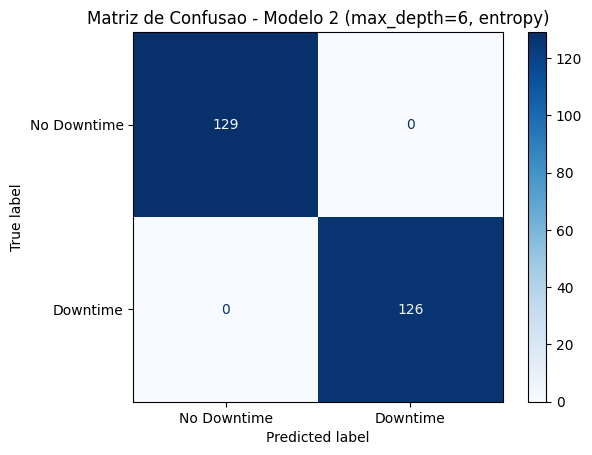

              precision    recall  f1-score   support

 No Downtime       1.00      1.00      1.00       129
    Downtime       1.00      1.00      1.00       126

    accuracy                           1.00       255
   macro avg       1.00      1.00      1.00       255
weighted avg       1.00      1.00      1.00       255



In [55]:
# ======= Matriz de Confusao - Melhor modelo =======
cm = confusion_matrix(y_test, y_pred2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Downtime', 'Downtime'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusao - Modelo 2 (max_depth=6, entropy)')
plt.show()
print(classification_report(y_test, y_pred2, target_names=['No Downtime', 'Downtime']))

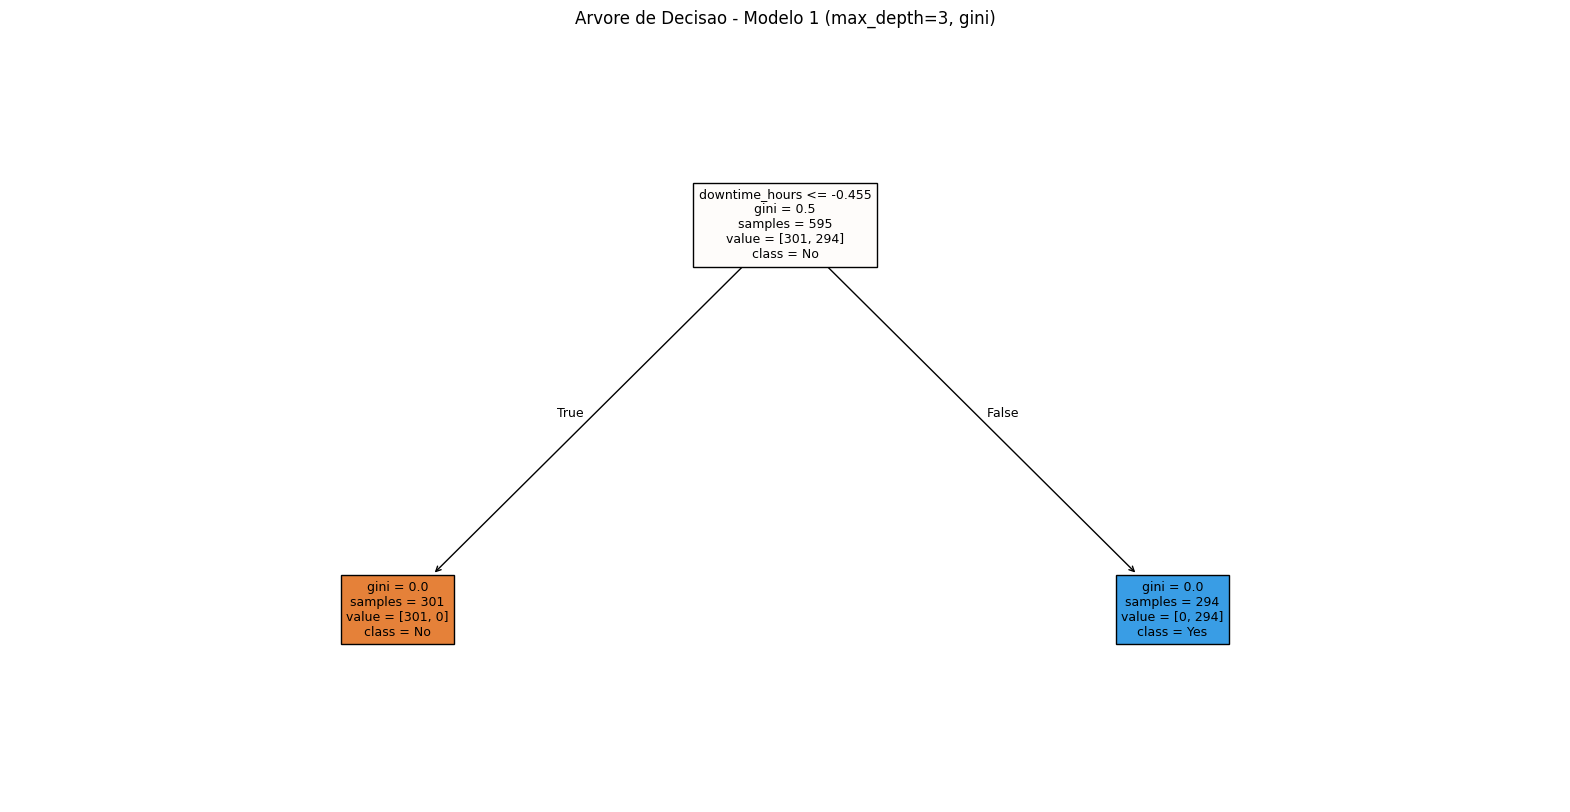

In [56]:
# ======= Visualizacao da Arvore (Modelo 1 - mais legivel) =======
plt.figure(figsize=(20, 10))
feature_names_short = [f[:25] for f in feature_names]
plot_tree(clf1, filled=True, feature_names=feature_names_short,
          class_names=['No', 'Yes'], fontsize=9, max_depth=3)
plt.title('Arvore de Decisao - Modelo 1 (max_depth=3, gini)')
plt.show()

### 3.1 Comparacao Prata vs Ouro

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# Comparacao Prata vs Ouro
# PRATA: df_ml sem feature engineering avancado (so fillna + get_dummies)
# OURO : df_ml com winsorizacao + scaling + OneHot (preprocessor completo)
# Ambos usam os mesmos registros (sem leakage, sem imputados)
# ══════════════════════════════════════════════════════════════════════
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X_prata = df_ml[num_skewed + num_normal + cat_cols].copy()
y_prata = df_ml[target].values

# Tratamento minimo da Prata: fillna + get_dummies (sem winsorizacao/scaling)
for c in num_skewed + num_normal:
    X_prata[c] = X_prata[c].fillna(0)
for c in cat_cols:
    X_prata[c] = X_prata[c].fillna('desconhecido').astype(str).str.lower().str.strip()
X_prata = pd.get_dummies(X_prata, columns=cat_cols, drop_first=True)

Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    X_prata, y_prata, test_size=0.3, random_state=42, stratify=y_prata
)
clf_prata = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_prata.fit(Xp_train, yp_train)
yp_pred = clf_prata.predict(Xp_test)

print('=' * 60)
print('PRATA  — sem feature engineering avancado')
print('=' * 60)
print(f'  Acuracia : {accuracy_score(yp_test, yp_pred):.4f}')
print(f'  Precisao : {precision_score(yp_test, yp_pred):.4f}')
print(f'  Recall   : {recall_score(yp_test, yp_pred):.4f}')
print(f'  F1-score : {f1_score(yp_test, yp_pred):.4f}')

print()
print('=' * 60)
print('OURO   — com winsorizacao + scaling + OneHot (preprocessor completo)')
print('=' * 60)
print(f'  Acuracia : {accuracy_score(y_test, y_pred1):.4f}')
print(f'  Precisao : {precision_score(y_test, y_pred1):.4f}')
print(f'  Recall   : {recall_score(y_test, y_pred1):.4f}')
print(f'  F1-score : {f1_score(y_test, y_pred1):.4f}')

print()
print('IMPACTO DO PRE-PROCESSAMENTO (Prata → Ouro):')
print(f'  Acuracia : {accuracy_score(yp_test, yp_pred):.4f}  →  {accuracy_score(y_test, y_pred1):.4f}')
print(f'  F1-score : {f1_score(yp_test, yp_pred):.4f}  →  {f1_score(y_test, y_pred1):.4f}')
print()
print('Nota: ambas as versoes usam df_ml (sem leakage, sem registros imputados).')
print('A diferenca reflete apenas o impacto do feature engineering da camada Ouro.')


## 4. Refatoracao PySpark

As celulas de refatoracao PySpark ja foram adicionadas aos 3 notebooks individuais:

| Notebook | Conteudo PySpark |
|---|---|
| `incedets_master.ipynb` | Bronze, Prata, Window, Ouro, Timing |
| `financial_impact.ipynb` | Bronze, Prata, Window, Ouro, Timing |
| `market_impact.ipynb` | Bronze, Prata, Window, Ouro, Timing |

### Operacoes implementadas em PySpark:
1. **Leitura Parquet** com `spark.read.parquet()`
2. **`df.join()`** com tipo explicto (`how="left"`) - substitui `pd.merge()`
3. **`groupBy().agg()`** do PySpark - substitui `df.groupby().agg()` do pandas
4. **`Window.partitionBy().orderBy()`** - media movel por vetor de ataque e ranking por setor
5. **Escrita Parquet** com `df.write.parquet()`
6. **Timing comparativo** Pandas vs PySpark com `time.time()`

### Evidencia de escalabilidade:
A celula de timing em cada notebook compara o tempo de execucao da mesma operacao
(deduplicacao + fill de nulos) em Pandas e PySpark, demonstrando os ganhos. 